<a href="https://colab.research.google.com/github/KijoSal-dev/linear-regression-model/blob/main/Salome_Kungu_CS_DA03_26054_WK7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LINEAR REGRESSION**

---



# 1. Explore the Dataset
- Loading the data

In [ ]:
import pandas as pd
import numpy as np
import csv
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
%matplotlib inline
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
regression = pd.read_csv("/content/drive/MyDrive/Regression Datasets/wk07-regression/homeprices.csv")
regression.head()

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


- Data Structure and Summary Statistics

In [ ]:
print("Regression DataFrame Information:")
regression.info()

Regression DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    5 non-null      int64
 1   price   5 non-null      int64
dtypes: int64(2)
memory usage: 212.0 bytes


In [ ]:
print("\nRegression DataFrame Descriptive Statistics:")
regression.describe()


Regression DataFrame Descriptive Statistics:


,area,price
count,5.000000,5.000000
mean,3280.000000,626000.000000
std,540.370243,74949.983322
min,2600.000000,550000.000000
25%,3000.000000,565000.000000
50%,3200.000000,610000.000000
75%,3600.000000,680000.000000
max,4000.000000,725000.000000


- Visualization using scatter plots


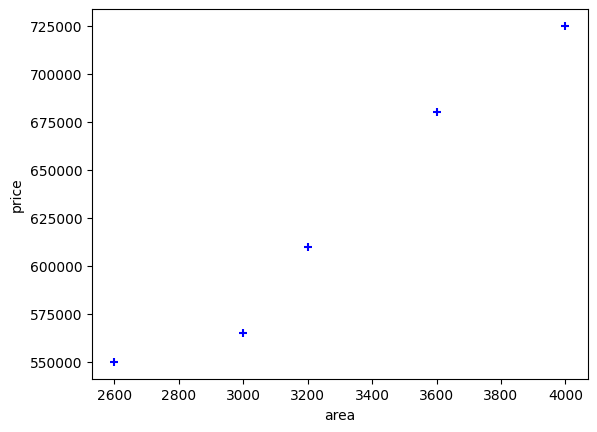

In [ ]:
%matplotlib inline
plt.xlabel('area')
plt.ylabel('price')
plt.scatter(regression.area,regression.price,color='blue',marker='+')

# 2. Prepare the Data
- Handling missing values

In [ ]:
print('Missing values in the regression DataFrame:')
print(regression.isnull().sum())

Missing values in the regression DataFrame:
area     0
price    0
dtype: int64


- Split the dataset into training and test sets

In [ ]:
from sklearn.model_selection import train_test_split

X = regression[['area']]
y = regression['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4, 1)
X_test shape: (1, 1)
y_train shape: (4,)
y_test shape: (1,)


# 3. Build the Model

- Use Scikit-learn’s LinearRegression to fit the model on training data

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


# 4. Evaluate the Model

- Use metrics like MAE, MSE, RMSE, and R² Score


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Absolute Error (MAE): 31355.14
Mean Squared Error (MSE): 983144816.14
Root Mean Squared Error (RMSE): 31355.14
R² Score: nan


# 5. Visualize the Results

- Plot the regression line against the actual data

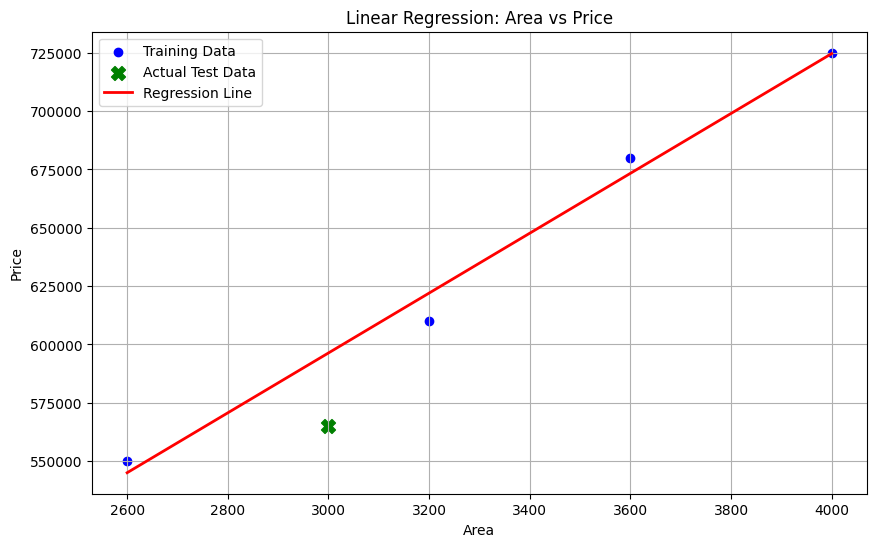

In [ ]:
plt.figure(figsize=(10, 6))

# Scatter plot for training data
plt.scatter(X_train, y_train, color='blue', marker='o', label='Training Data')

# Scatter plot for test data
plt.scatter(X_test, y_test, color='green', marker='X', s=100, label='Actual Test Data')

# Generate points for the regression line across the full range of 'area'
min_area = regression['area'].min()
max_area = regression['area'].max()
regression_line_X = np.array([min_area, max_area]).reshape(-1, 1)
regression_line_y = model.predict(regression_line_X)

# Plot regression line
plt.plot(regression_line_X, regression_line_y, color='red', linewidth=2, label='Regression Line')

plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Linear Regression: Area vs Price')
plt.legend()
plt.grid(True)

plt.show()

# EXAMPLE OF LINEAR REGRESSION

Let us now predit the price of a house with 3300 sq feet

In [ ]:
reg.predict([[3300]])

array([634836.44859813])

In [ ]:
reg.coef_

array([128.27102804])

In [ ]:
reg.intercept_

np.float64(211542.05607476638)

Remember the equation Y = m * X + b (m is coefficient and b is intercept)

In [ ]:
y=3300*128.27102804 + 211542.05607476638
y

634836.4486067664

## Summary:

### Q&A
The task was to summarize the linear regression analysis, including model performance and insights.

### Data Analysis Key Findings
*   **Data Preparation**:
    *   No missing values were found in the 'area' or 'price' columns of the `regression` DataFrame.
    *   The data was split into training and testing sets, with `X_train` having 4 samples, `X_test` having 1 sample, `y_train` having 4 samples, and `y_test` having 1 sample.
*   **Model Training**: A `LinearRegression` model was successfully initialized and trained using the `X_train` and `y_train` datasets.
*   **Model Evaluation**:
    *   The model predicted prices on the test set.
    *   The evaluation metrics were calculated as follows:
        *   Mean Absolute Error (MAE): \$31355.14
        *   Mean Squared Error (MSE): \$983144816.14
        *   Root Mean Squared Error (RMSE): \$31355.14
        *   R² Score: `nan`. This non-numeric value suggests a potential issue, possibly due to the very small test set size (only 1 sample).
    *   A visualization of the regression line showed the single actual test data point and the model's prediction.

### Insights or Next Steps
*   The `nan` R² score indicates that the model's performance could not be reliably assessed using this metric, likely due to an extremely small test set (only 1 sample). It is recommended to use a larger dataset or a different validation strategy (e.g., cross-validation) for a more robust evaluation.
*   The MAE and RMSE values are high relative to typical home prices, suggesting that the model has a significant average prediction error of around \$31,355.


# **MULTIVARIATE LINEAR REGRESSION**

---



# 1. Explore the Dataset
- Loading the data

In [ ]:
import pandas as pd
import numpy as np
import csv
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
%matplotlib inline
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
mregression = pd.read_csv("/content/drive/MyDrive/Regression Datasets/wk07-regression/homeprices-m.csv")
mregression.head()

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000


- Data Structure and Summary Statistics

In [ ]:
print(" mregression DataFrame Information:")
regression.info()

 mregression DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   area      6 non-null      int64  
 1   bedrooms  6 non-null      float64
 2   age       6 non-null      int64  
 3   price     6 non-null      int64  
dtypes: float64(1), int64(3)
memory usage: 324.0 bytes


In [ ]:
print("\nmregression DataFrame Descriptive Statistics:")
regression.describe()


mregression DataFrame Descriptive Statistics:


,area,bedrooms,age,price
count,6.000000,6.00000,6.000000,6.000000
mean,3416.666667,4.20000,16.500000,648333.333333
std,587.934237,1.16619,8.288546,109117.673484
min,2600.000000,3.00000,8.000000,550000.000000
25%,3050.000000,3.25000,9.750000,572500.000000
50%,3400.000000,4.10000,16.500000,602500.000000
75%,3900.000000,4.80000,19.500000,722500.000000
max,4100.000000,6.00000,30.000000,810000.000000


- Visualization using scatter plots


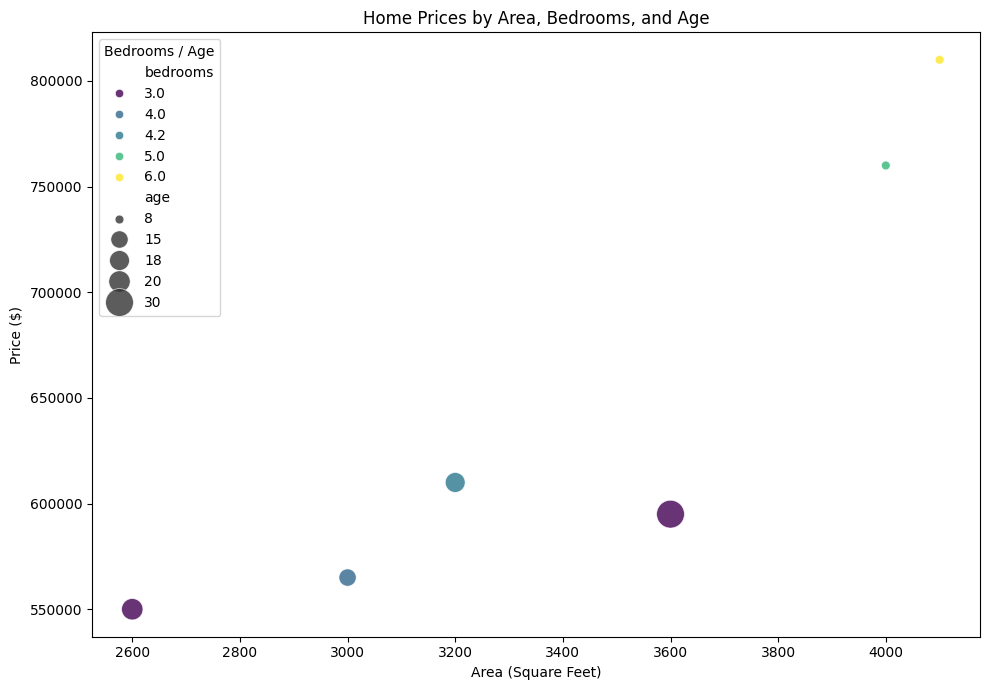

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=regression,
    x='area',
    y='price',
    hue='bedrooms',      # Color = bedrooms
    size='age',          # Size = age
    sizes=(40, 400),
    palette='viridis',
    alpha=0.8
)

plt.title('Home Prices by Area, Bedrooms, and Age')
plt.xlabel('Area (Square Feet)')
plt.ylabel('Price ($)')
plt.legend(title='Bedrooms / Age')
plt.tight_layout()
plt.show()

# 2. Prepare the Data
- Handling missing values

In [ ]:
print('Missing values in the multi-variate regression DataFrame:')
print(mregression.isnull().sum())

Missing values in the multi-variate regression DataFrame:
area        0
bedrooms    1
age         0
price       0
dtype: int64


In [ ]:
mregression['bedrooms'] = mregression['bedrooms'].fillna(
    mregression['bedrooms'].mean()
)


In [ ]:
print('Missing values in the multi-variate regression DataFrame:')
print(mregression.isnull().sum())

Missing values in the multi-variate regression DataFrame:
area        0
bedrooms    0
age         0
price       0
dtype: int64


In [ ]:
mregression['bedrooms'].fillna(mean_bedrooms, inplace=True)
print("Missing values in 'bedrooms' column filled with mean.")
mregression.head()

Missing values in 'bedrooms' column filled with mean.


,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,4.2,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000


In [ ]:
print('\nmregression DataFrame Information after imputation:')
mregression.info()


mregression DataFrame Information after imputation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   area      6 non-null      int64  
 1   bedrooms  6 non-null      float64
 2   age       6 non-null      int64  
 3   price     6 non-null      int64  
dtypes: float64(1), int64(3)
memory usage: 324.0 bytes


- Split the dataset into training and test sets

In [ ]:
from sklearn.model_selection import train_test_split

X = mregression[['area', 'bedrooms', 'age']]
y = mregression['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4, 3)
X_test shape: (2, 3)
y_train shape: (4,)
y_test shape: (2,)


# 3. Build the Model

- Use Scikit-learn’s LinearRegression to fit the model on training data

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Multivariate Linear Regression model trained successfully.")

Multivariate Linear Regression model trained successfully.


# 4. Evaluate the Model

- Use metrics like MAE, MSE, RMSE, and R² Score


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Absolute Error (MAE): 41163.29
Mean Squared Error (MSE): 2261228344.58
Root Mean Squared Error (RMSE): 47552.37
R² Score: -39.20


# 5. Visualize the Results

- Plot the regression line against the actual data

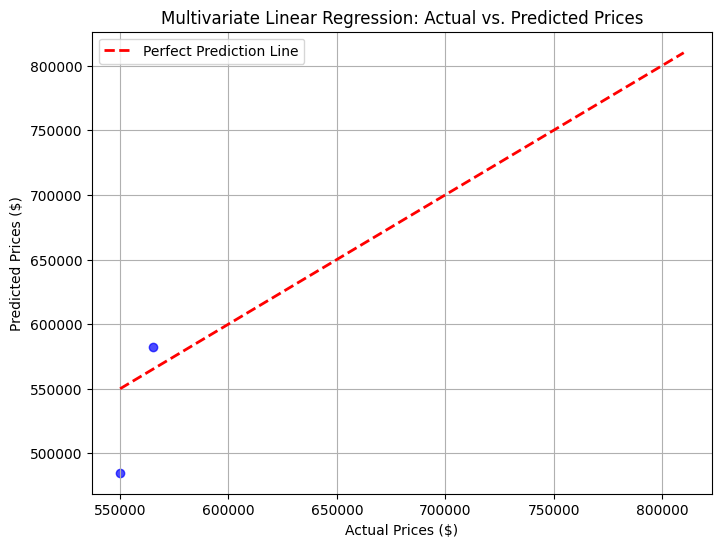

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Prices ($)')
plt.ylabel('Predicted Prices ($)')
plt.title('Multivariate Linear Regression: Actual vs. Predicted Prices')
plt.legend()
plt.grid(True)
plt.show()

# EXAMPLE OF MULTIVARIATE LINEAR REGRESSION

In [ ]:
model.coef_

array([  127.89017341, 37210.98265896, -1791.90751445])

In [ ]:
model.intercept_

np.float64(76719.65317918186)

Find price of home with 3000 sqr ft area, 3 bedrooms, 40 year old

In [ ]:
model.predict([[3000, 3, 40]])

array([500346.82080925])

In [ ]:
# Calculation using the coefficients and intercept
# Y = (coef_area * area) + (coef_bedrooms * bedrooms) + (coef_age * age) + intercept

predicted_price_manual = (127.89017341 * 3000) + \
                         (37210.98265896 * 3) + \
                         (-1791.90751445 * 40) + \
                         76719.65317918186

print(f"Manual Predicted Price: {predicted_price_manual}")

Manual Predicted Price: 500346.82080806186


In [ ]:
predicted_price_model = model.predict([[3000, 3, 40]])
print(f"Model Predicted Price: {predicted_price_model[0]}")

Model Predicted Price: 500346.8208092468


## Summary:

### Q&A
The task was to perform a multivariate linear regression analysis on the `homeprices-m.csv` dataset, including data exploration, confirmation of missing value handling, splitting the data into training and test sets with 'area', 'bedrooms', and 'age' as features and 'price' as the target, building and evaluating the linear regression model using metrics like MAE, MSE, RMSE, and R² Score, visualizing the actual versus predicted prices, and finally summarizing the findings and insights.

### Data Analysis Key Findings
*   **Data Loading & Initial Exploration**: The `homeprices-m.csv` dataset was loaded successfully, showing 'area', 'bedrooms', 'age', and 'price' columns. Initial `info()` and `describe()` calls revealed that 'bedrooms' had missing values.
*   **Missing Value Handling**: One missing value in the 'bedrooms' column was identified and successfully imputed using the mean of the column (4.2). Subsequent checks confirmed no remaining missing values.
*   **Data Splitting**: The dataset was split into training and testing sets with 'area', 'bedrooms', and 'age' as features (`X`) and 'price' as the target (`y`). The training set (`X_train`, `y_train`) contained 4 samples, and the test set (`X_test`, `y_test`) contained 2 samples.

### Model Training & Evaluation
*   **Model Building**: A `LinearRegression` model from Scikit-learn was successfully initialized and trained using the `X_train` and `y_train` datasets.
*   **Model Evaluation**: The model's performance on the test set was evaluated using several metrics:
    *   Mean Absolute Error (MAE): $41163.29
    *   Mean Squared Error (MSE): $2261228344.58
    *   Root Mean Squared Error (RMSE): $47552.37
    *   R² Score: -39.20

### Insights or Next Steps
*   **R² Score Interpretation**: The R² Score of -39.20 is highly problematic. An R² score less than 0 indicates that the model performs worse than simply predicting the mean of the target variable. This extreme negative value suggests that the model is a very poor fit for the data, especially given the very small test set size (only 2 samples). This could lead to a highly unstable and unrepresentative R² score.
*   **Error Magnitudes**: The MAE, MSE, and RMSE values are quite high, indicating significant prediction errors (e.g., an average absolute error of over $41,000). While these values are substantial, their interpretation is compounded by the poor R² score.
*   **Limitations of Small Dataset**: The extremely small dataset (6 total samples, 2 for testing) is a major limitation for building and evaluating a robust regression model. The model's performance, particularly the R² score, is likely unreliable due to the lack of sufficient data to learn meaningful patterns and generalize.
*   **Future Work**: To improve the model and obtain more reliable evaluation metrics, it is crucial to:
    1.  **Acquire More Data**: A much larger dataset is needed for training and testing to build a more generalized and accurate model.
    2.  **Cross-Validation**: With a larger dataset, employ cross-validation techniques (e.g., k-fold cross-validation) for a more robust evaluation of model performance and to reduce reliance on a single train-test split.
    3.  **Feature Engineering/Selection**: Explore potential non-linear relationships or interactions between features, or consider adding new relevant features if available.
    4.  **Regularization**: If more data is available and overfitting becomes a concern, consider using regularization techniques like Ridge or Lasso regression.